# Minimal-intersection knot diagrams from PD and Gauss code

This notebook walks through a dependency-free version of the pipeline from Philip Rideout's
[Generating SVG for the Prime Knots](https://prideout.net/blog/svg_knots/):

`Gauss code -> combinatorial embedding -> half-edge structure -> circle packing -> SVG`

The goal is to turn a combinatorial knot description into 2D coordinates for a planar
shadow graph. If the input code is a minimal crossing diagram for the knot, the drawing
preserves that crossing count: the layout process adds no accidental intersections.


## Inputs

There are two supported entry points.

- **Enhanced Gauss code.** A visit such as `3 oa` means "crossing 3, over strand, local
  orientation `a`." The orientation bit is the extra information described in the blog post;
  a plain signed Gauss word does not uniquely determine the planar embedding.
- **Standard PD notation.** A tuple `X[a,b,c,d]` lists the four incident edge labels around a
  crossing, starting at the incoming under edge and proceeding counterclockwise, matching the
  Knot Atlas / KnotTheory convention.

For convenience, the notebook also includes a small Kauffman-orientation helper that upgrades
signed Gauss words to the enhanced form for classical one-component knots.


In [1]:
import math
import re
from html import escape

try:
    from IPython.display import SVG, display
except Exception:
    SVG = None
    display = None


GAUSS_EXAMPLES = {
    "3_1": "1 oa 2 ua 3 oa 1 ua 2 oa 3 ua",
    "4_1": "1 uc 2 oa 3 ua 1 oc 4 uc 3 oa 2 ua 4 oc",
    "5_1": "1 uc 2 oc 3 uc 4 oc 5 uc 1 oc 2 uc 3 oc 4 uc 5 oc",
    "5_2": "1 oa 2 ua 3 oa 1 ua 4 oa 5 ua 2 oa 3 ua 5 oa 4 ua",
    "6_1": "1 oa 2 ua 3 oc 4 uc 2 oa 1 ua 5 oa 6 ua 4 oc 3 uc 6 oa 5 ua",
    "6_2": "1 oa 2 ua 3 oc 4 uc 5 oc 6 uc 2 oa 1 ua 6 oc 3 uc 4 oc 5 uc",
    "6_3": "1 uc 2 oc 3 uc 1 oc 4 ua 5 oa 2 uc 3 oc 6 ua 4 oa 5 ua 6 oa",
    "7_4": "1 uc 2 oc 3 uc 4 oc 5 uc 6 oc 7 uc 3 oc 2 uc 1 oc 4 uc 7 oc 6 uc 5 oc",
    "8_11": "1 oa 2 ua 3 oc 4 uc 5 oc 6 uc 7 oc 8 uc 2 oa 1 ua 8 oc 3 uc 6 oc 5 uc 4 oc 7 uc",
}


TREFOIL_PD = [
    (4, 2, 5, 1),
    (6, 4, 1, 3),
    (2, 6, 3, 5),
]


def show_svg(svg):
    if SVG is None or display is None:
        print(svg)
    else:
        display(SVG(svg))


# ---------------------------------------------------------------------------
# Circle packing, ported from David Eppstein's PADS implementation of the
# Collins-Stephenson algorithm. This is intentionally dependency-free.

TOLERANCE = 1 + 1e-11


def _angle_from_radii(x, y, z):
    try:
        numerator = (x + y) ** 2 + (x + z) ** 2 - (y + z) ** 2
        denominator = 2.0 * (x + y) * (x + z)
        return math.acos(numerator / denominator)
    except ValueError:
        return math.pi / 3
    except ZeroDivisionError:
        return math.pi


def _flower_angle(radius, center, cycle):
    return sum(
        _angle_from_radii(radius[center], radius[cycle[i - 1]], radius[cycle[i]])
        for i in range(len(cycle))
    )


def _place(placements, radii, internal, center):
    if center not in internal:
        return
    cycle = internal[center]
    for i in range(-len(cycle), len(cycle) - 1):
        if cycle[i] in placements and cycle[i + 1] not in placements:
            s, t = cycle[i], cycle[i + 1]
            theta = _angle_from_radii(radii[center], radii[s], radii[t])
            offset = (placements[s] - placements[center]) / (radii[s] + radii[center])
            offset *= math.e ** (-1j * theta)
            placements[t] = placements[center] + offset * (radii[t] + radii[center])
            _place(placements, radii, internal, t)


def circle_pack(internal, external):
    if not internal:
        raise ValueError("circle_pack needs at least one internal circle")
    if min(external.values()) <= 0:
        raise ValueError("external radii must be positive")

    radii = dict(external)
    for key in internal:
        if key in external:
            raise ValueError("internal and external keys must be disjoint")
        radii[key] = 1.0

    last_change = 2.0
    while last_change > TOLERANCE:
        last_change = 1.0
        for key in internal:
            theta = _flower_angle(radii, key, internal[key])
            hat = radii[key] / (1.0 / math.sin(theta / (2 * len(internal[key]))) - 1.0)
            new_radius = hat * (1.0 / math.sin(math.pi / len(internal[key])) - 1.0)
            ratio = max(new_radius / radii[key], radii[key] / new_radius)
            last_change = max(last_change, ratio)
            radii[key] = new_radius

    placements = {}
    first = next(iter(internal))
    second = internal[first][0]
    placements[first] = 0j
    placements[second] = radii[first] + radii[second]
    _place(placements, radii, internal, first)
    _place(placements, radii, internal, second)

    missing = set(radii) - set(placements)
    if missing:
        raise RuntimeError(f"circle packing failed to place: {sorted(missing)}")
    return {key: (placements[key], radii[key]) for key in radii}


# ---------------------------------------------------------------------------
# From Gaussian code to an embedded 4-regular shadow graph.

def _crosses(pair_a, pair_b):
    a, b = pair_a
    c, d = pair_b
    if c < a:
        a, b, c, d = c, d, a, b
    return a < c < b < d


def _bipartition_intersection_graph(pairings):
    colors = {}
    for start in range(len(pairings)):
        if start in colors:
            continue
        colors[start] = 0
        stack = [start]
        while stack:
            u = stack.pop()
            for v in range(len(pairings)):
                if u == v or not _crosses(pairings[u], pairings[v]):
                    continue
                wanted = 1 - colors[u]
                if v in colors:
                    if colors[v] != wanted:
                        raise ValueError("the Gauss word is not classical-planar")
                else:
                    colors[v] = wanted
                    stack.append(v)
    return colors


def recover_orientations(sage_signed_gauss):
    """Recover Kauffman local orientations.

    The input follows Sage's convention: negative means over-crossing,
    positive means under-crossing.
    """
    signs_overunder = [1 if letter > 0 else -1 for letter in sage_signed_gauss]
    gauss = [abs(x) for x in sage_signed_gauss]
    n = len(gauss) // 2

    changed = list(gauss)
    for label in range(1, n + 1):
        first = changed.index(label)
        start = changed[: first + 1]
        after_first = changed[first + 1 :]
        second = after_first.index(label)
        changed = start + list(reversed(after_first[:second])) + after_first[second:]

    positions = [[] for _ in range(n)]
    for position, label in enumerate(changed):
        positions[label - 1].append(position)
    pairings = [tuple(pair) for pair in positions]
    colors = _bipartition_intersection_graph(pairings)

    positive = sorted(pairings[index] for index, color in colors.items() if color == 0)
    negative = sorted(pairings[index] for index, color in colors.items() if color == 1)

    signs_local = {label: 1 for label in range(1, n + 1)}
    for left, _ in negative:
        signs_local[changed[left]] *= -1

    jump_from = {}
    for left, right in positive + negative:
        jump_from[left] = right
        jump_from[right] = left

    direction = 1
    position = 0
    for step in range(2 * n):
        label = changed[position]
        new_position = jump_from[position]
        sign = signs_local[label]
        if new_position < position:
            sign = -sign
        if direction == 1:
            sign *= signs_overunder[step]
        signs_local[label] = sign
        direction = -direction
        position = new_position + direction

    return [signs_local[label] for label in range(1, n + 1)]


def signed_gauss_to_enhanced(word, over_is_positive=True):
    """Add the a/c orientation bit to a signed Gauss word."""
    labels = sorted(set(abs(value) for value in word))
    if labels != list(range(1, len(labels) + 1)):
        raise ValueError("signed Gauss labels should be 1..n")
    for label in labels:
        if sum(1 for value in word if abs(value) == label) != 2:
            raise ValueError(f"label {label} does not appear exactly twice")

    sage_word = []
    over_under = []
    for value in word:
        is_over = value > 0 if over_is_positive else value < 0
        label = abs(value)
        sage_word.append(-label if is_over else label)
        over_under.append("o" if is_over else "u")

    local_signs = recover_orientations(sage_word)
    orientation = {label: ("c" if local_signs[label - 1] == 1 else "a") for label in labels}
    return " ".join(
        f"{abs(value)} {over_under[index]}{orientation[abs(value)]}"
        for index, value in enumerate(word)
    )


def _parse_enhanced_gauss(text):
    entries = [(int(label), descriptor.lower()) for label, descriptor in re.findall(r"(\d+)\s*([ou][ac])", text)]
    if not entries:
        raise ValueError("expected tokens like '1 oa 2 uc ...'")
    labels = sorted({label for label, _ in entries})
    id_for_label = {label: index for index, label in enumerate(labels)}
    normalized = [(id_for_label[label], descriptor) for label, descriptor in entries]
    n = len(labels)
    if len(normalized) != 2 * n:
        raise ValueError("a one-component Gauss word should have exactly 2n visits")
    return normalized, n


def nodes_from_gauss(text):
    entries, n = _parse_enhanced_gauss(text)
    m = 2 * n
    positions = {}
    for position, entry in enumerate(entries):
        positions.setdefault(entry[0], []).append((position, entry[1]))

    rotations = {}
    node_types = {}
    for crossing in range(n):
        visits = positions.get(crossing, [])
        if len(visits) != 2:
            raise ValueError(f"crossing {crossing + 1} does not appear exactly twice")
        (p, first), (q, second) = visits
        if p > q:
            (p, first), (q, second) = (q, second), (p, first)
        if first[1] != second[1] or first[0] == second[0]:
            raise ValueError("each crossing needs one over visit, one under visit, and one a/c bit")

        after_first = n + p
        before_first = n + ((p - 1) % m)
        after_second = n + q
        before_second = n + ((q - 1) % m)

        if first in ("oa", "uc"):
            order = [after_first, after_second, before_first, before_second]
        else:
            order = [after_first, before_second, before_first, after_second]

        rotations[crossing] = order
        node_types[crossing] = "over" if first[0] == "o" else "under"

    for position in range(m):
        source = entries[position][0]
        sink = entries[(position + 1) % m][0]
        rotations[n + position] = [source, sink]

    return build_meta_graph(rotations, node_types)


# ---------------------------------------------------------------------------
# From standard PD notation to the same embedded shadow graph.

def pd_to_signed_gauss(pd, over_is_positive=True):
    incoming = {}
    outgoing = {}
    for crossing, (a, b, c, d) in enumerate(pd, start=1):
        incoming[a] = (crossing, "u")
        outgoing[a] = c
        incoming[d] = (crossing, "o")
        outgoing[d] = b

    labels = sorted(incoming)
    if set(outgoing) != set(labels):
        raise ValueError("PD labels should form one closed component")

    relabel = {}
    result = []
    current = labels[0]
    seen_edges = set()
    for _ in range(len(labels)):
        if current in seen_edges:
            raise ValueError("PD traversal closed before all edges were seen")
        seen_edges.add(current)
        crossing, over_under = incoming[current]
        if crossing not in relabel:
            relabel[crossing] = len(relabel) + 1
        sign = 1 if over_under == "o" else -1
        if not over_is_positive:
            sign *= -1
        result.append(sign * relabel[crossing])
        current = outgoing[current]

    if current != labels[0] or seen_edges != set(labels):
        raise ValueError("this helper expects a one-component PD code")
    return result


def nodes_from_pd(pd):
    n = len(pd)
    labels = sorted({label for crossing in pd for label in crossing})
    arc_id = {label: n + index for index, label in enumerate(labels)}
    rotations = {}
    node_types = {}
    arc_occurrences = {label: [] for label in labels}

    for crossing, (a, b, c, d) in enumerate(pd):
        # PD gives counterclockwise order starting at the incoming under edge.
        # The renderer expects clockwise order with positions 0 and 2 on the
        # same strand, so use a, d, c, b.
        clockwise_labels = [a, d, c, b]
        rotations[crossing] = [arc_id[label] for label in clockwise_labels]
        node_types[crossing] = "under"
        for label in clockwise_labels:
            arc_occurrences[label].append(crossing)

    for label, endpoints in arc_occurrences.items():
        if len(endpoints) != 2:
            raise ValueError(f"PD edge label {label} appears {len(endpoints)} times")
        rotations[arc_id[label]] = endpoints

    return build_meta_graph(rotations, node_types)


# ---------------------------------------------------------------------------
# Half-edge face walk and meta-graph construction.

def walk_faces(rotations, turn=1):
    seen = set()
    directed_face = {}
    faces = []

    for source in sorted(rotations):
        for target in rotations[source]:
            if (source, target) in seen:
                continue
            face_id = len(faces)
            face = []
            a, b = source, target
            while (a, b) not in seen:
                seen.add((a, b))
                directed_face[(a, b)] = face_id
                face.append(b)
                cycle = rotations[b]
                index = cycle.index(a)
                a, b = b, cycle[(index + turn) % len(cycle)]
            faces.append(face)
    return faces, directed_face


def build_meta_graph(rotations, node_types):
    faces, directed_face = walk_faces(rotations)
    face_offset = max(rotations) + 1
    nodes = [None] * (face_offset + len(faces))

    for node in range(face_offset):
        rotation = rotations[node]
        neighbors = []
        for index, neighbor in enumerate(rotation):
            next_neighbor = rotation[(index + 1) % len(rotation)]
            neighbors.append(neighbor)
            neighbors.append(face_offset + directed_face[(node, next_neighbor)])
        nodes[node] = [node_types.get(node, "arc"), neighbors]

    for index, face in enumerate(faces):
        # The walk records the face on the opposite side from the clockwise
        # rotations used by crossing and arc nodes. Reverse it so the packing
        # receives one consistent orientation around every circle.
        face_cycle = list(reversed(face))
        while node_types.get(face_cycle[0], "arc") != "arc":
            face_cycle = face_cycle[1:] + face_cycle[:1]
        nodes[face_offset + index] = ["face", face_cycle]
    return nodes


def face_ids(nodes):
    return [index for index, (kind, _) in enumerate(nodes) if kind == "face"]


def choose_outer_face(nodes):
    return max(face_ids(nodes), key=lambda face: len(nodes[face][1]))


def layout_nodes(nodes, outer_face=None):
    faces = face_ids(nodes)
    if outer_face is None:
        outer = choose_outer_face(nodes)
    elif outer_face in faces:
        outer = outer_face
    else:
        outer = faces[outer_face]

    internal = {index: list(neighbors) for index, (_, neighbors) in enumerate(nodes)}
    for index in list(internal):
        internal[index] = [neighbor for neighbor in internal[index] if neighbor != outer]

    external = {}
    for index in nodes[outer][1]:
        internal.pop(index, None)
        external[index] = 1.0
    internal.pop(outer, None)

    return circle_pack(internal, external), outer


# ---------------------------------------------------------------------------
# SVG rendering.

def _xy(point):
    return f"{point.real:.5f} {point.imag:.5f}"


def _tangent(layout, circle, neighbor):
    center, radius = layout[circle]
    other, _ = layout[neighbor]
    direction = other - center
    if abs(direction) == 0:
        return center
    return center + radius * direction / abs(direction)


def _cubic_on_circle(layout, circle, neighbor0, neighbor1, bend=0.5):
    center, _ = layout[circle]
    p0 = _tangent(layout, circle, neighbor0)
    p1 = _tangent(layout, circle, neighbor1)
    c0 = center * (1 - bend) + p0 * bend
    c1 = center * (1 - bend) + p1 * bend
    return f"M {_xy(p0)} C {_xy(c0)}, {_xy(c1)}, {_xy(p1)}"


def _stroke_width(layout, circle, neighbor0, neighbor1):
    _, radius = layout[circle]
    _, r0 = layout[neighbor0]
    _, r1 = layout[neighbor1]
    return max(0.025, 0.15 * (2 * radius + r0 + r1))


def svg_scene(nodes, outer_face=None, show_circles=False, labels=False):
    layout, outer = layout_nodes(nodes, outer_face)

    min_x = min(center.real - radius for center, radius in layout.values())
    min_y = min(center.imag - radius for center, radius in layout.values())
    max_x = max(center.real + radius for center, radius in layout.values())
    max_y = max(center.imag + radius for center, radius in layout.values())
    pad = 0.08 * max(max_x - min_x, max_y - min_y)
    view_box = f"{min_x - pad:.5f} {min_y - pad:.5f} {(max_x - min_x) + 2 * pad:.5f} {(max_y - min_y) + 2 * pad:.5f}"

    parts = [
        '<rect x="-10000" y="-10000" width="20000" height="20000" fill="white"/>'
    ]

    if show_circles:
        colors = {"face": "#f8dca7", "arc": "#bfe5f2", "over": "#e8e8e8", "under": "#e8e8e8"}
        for index, (center, radius) in sorted(layout.items()):
            kind = nodes[index][0]
            parts.append(
                f'<circle cx="{center.real:.5f}" cy="{center.imag:.5f}" r="{radius:.5f}" '
                f'fill="{colors[kind]}" stroke="#ffffff" stroke-width="{0.01 * radius:.5f}" opacity="0.86"/>'
            )

    # First draw the long arcs between crossing disks.
    for index, (kind, neighbors) in enumerate(nodes):
        if kind != "arc" or index not in layout:
            continue
        crossings = [neighbor for neighbor in neighbors[::2] if nodes[neighbor][0] in ("over", "under")]
        if len(crossings) != 2 or any(crossing not in layout for crossing in crossings):
            continue
        path = _cubic_on_circle(layout, index, crossings[0], crossings[1])
        width = _stroke_width(layout, index, crossings[0], crossings[1])
        parts.append(
            f'<path d="{path}" fill="none" stroke="black" stroke-width="{width:.5f}" '
            'stroke-linecap="round" stroke-linejoin="round"/>'
        )

    # Then draw the crossing disks with the whiteout layer under the over strand.
    for index, (kind, neighbors) in enumerate(nodes):
        if kind not in ("over", "under") or index not in layout:
            continue
        arcs = [neighbor for neighbor in neighbors[::2] if nodes[neighbor][0] == "arc"]
        if len(arcs) != 4 or any(arc not in layout for arc in arcs):
            continue

        if kind == "over":
            under_pair = (arcs[3], arcs[1])
            over_pair = (arcs[0], arcs[2])
        else:
            under_pair = (arcs[0], arcs[2])
            over_pair = (arcs[3], arcs[1])

        for pair, color, multiplier in [
            (under_pair, "black", 1.0),
            (over_pair, "white", 2.35),
            (over_pair, "black", 1.0),
        ]:
            path = _cubic_on_circle(layout, index, pair[0], pair[1], bend=0.52)
            width = _stroke_width(layout, index, pair[0], pair[1]) * multiplier
            parts.append(
                f'<path d="{path}" fill="none" stroke="{color}" stroke-width="{width:.5f}" '
                'stroke-linecap="round" stroke-linejoin="round"/>'
            )

    if labels:
        for index, (center, radius) in sorted(layout.items()):
            kind = nodes[index][0]
            label = f"{kind[0]}{index}"
            parts.append(
                f'<text x="{center.real:.5f}" y="{center.imag:.5f}" text-anchor="middle" '
                f'dominant-baseline="central" font-size="{0.28 * radius:.5f}" '
                'font-family="ui-monospace, SFMono-Regular, Menlo, monospace" '
                f'fill="#333">{escape(label)}</text>'
            )

    return view_box, "\n".join(parts), outer


def render_svg(nodes, outer_face=None, show_circles=False, labels=False, width=420, height=420):
    view_box, body, _ = svg_scene(nodes, outer_face, show_circles, labels)
    return (
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" '
        f'viewBox="{view_box}" role="img">\n{body}\n</svg>'
    )


def gallery_svg(items, columns=3, cell_width=220, cell_height=240):
    rows = (len(items) + columns - 1) // columns
    total_width = columns * cell_width
    total_height = rows * cell_height
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{total_width}" height="{total_height}" '
        f'viewBox="0 0 {total_width} {total_height}" role="img">',
        '<rect width="100%" height="100%" fill="white"/>',
    ]

    for index, item in enumerate(items):
        label = item["label"]
        nodes = item["nodes"]
        outer = item.get("outer_face")
        show_circles = item.get("show_circles", False)
        view_box, body, _ = svg_scene(nodes, outer, show_circles)
        col = index % columns
        row = index // columns
        x = col * cell_width
        y = row * cell_height
        parts.append(
            f'<svg x="{x + 8}" y="{y + 8}" width="{cell_width - 16}" height="{cell_height - 38}" '
            f'viewBox="{view_box}">{body}</svg>'
        )
        parts.append(
            f'<text x="{x + cell_width / 2:.1f}" y="{y + cell_height - 12}" text-anchor="middle" '
            'font-family="ui-sans-serif, -apple-system, BlinkMacSystemFont, Segoe UI, sans-serif" '
            f'font-size="14" fill="#222">{escape(label)}</text>'
        )

    parts.append("</svg>")
    return "\n".join(parts)


def crossing_coordinates(nodes, outer_face=None):
    layout, outer = layout_nodes(nodes, outer_face)
    rows = []
    for index, (kind, _) in enumerate(nodes):
        if kind in ("over", "under") and index in layout:
            center, radius = layout[index]
            rows.append((index, kind, center.real, center.imag, radius))
    return outer, rows


def describe_nodes(nodes):
    lines = []
    for index, (kind, neighbors) in enumerate(nodes):
        lines.append(f"{index:2d} {kind:5s} {neighbors}")
    return "\n".join(lines)


## Walkthrough 1: signed Gauss code

The trefoil has three crossings and six visits. The first code cell upgrades a plain signed
word to the blog's enhanced Gauss code, then constructs the meta-graph used for packing.

In the node table, `over` and `under` are crossing circles, `arc` nodes are the diagram arcs
between consecutive visits, and `face` nodes are discovered by the half-edge walk.


signed Gauss:   [1, -2, 3, -1, 2, -3]
enhanced Gauss: 1 oa 2 ua 3 oa 1 ua 2 oa 3 ua

meta-graph nodes:
 0 over  [3, 10, 6, 11, 8, 12, 5, 9]
 1 under [4, 11, 6, 10, 3, 9, 7, 13]
 2 over  [5, 12, 8, 11, 4, 13, 7, 9]
 3 arc   [0, 9, 1, 10]
 4 arc   [1, 13, 2, 11]
 5 arc   [2, 9, 0, 12]
 6 arc   [0, 10, 1, 11]
 7 arc   [1, 9, 2, 13]
 8 arc   [2, 12, 0, 11]
 9 face  [5, 2, 7, 1, 3, 0]
10 face  [3, 1, 6, 0]
11 face  [6, 1, 4, 2, 8, 0]
12 face  [8, 2, 5, 0]
13 face  [7, 2, 4, 1]


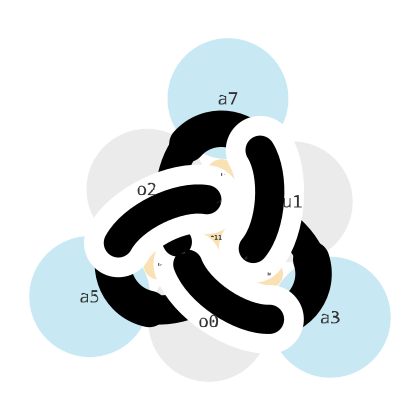

In [2]:
signed = [1, -2, 3, -1, 2, -3]  # positive means over in this cell
enhanced = signed_gauss_to_enhanced(signed, over_is_positive=True)
trefoil = nodes_from_gauss(enhanced)

print("signed Gauss:  ", signed)
print("enhanced Gauss:", enhanced)
print()
print("meta-graph nodes:")
print(describe_nodes(trefoil))

show_svg(render_svg(trefoil, show_circles=True, labels=True))


## Walkthrough 2: PD code

The PD path skips Kauffman's recovery step because PD notation already gives the cyclic order
of the four half-edges around every crossing. The code below uses the same trefoil, but starts
from `X[a,b,c,d]` tuples.


PD code:
  X(4, 2, 5, 1)
  X(6, 4, 1, 3)
  X(2, 6, 3, 5)
signed Gauss recovered from PD: [1, -2, 3, -1, 2, -3]


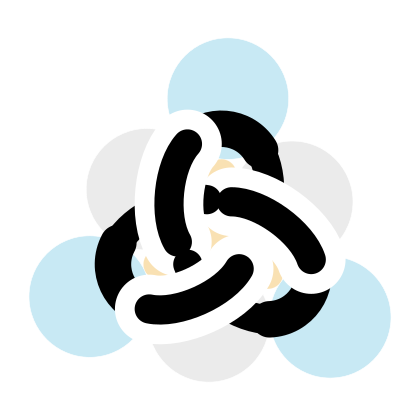

In [3]:
pd = TREFOIL_PD
pd_nodes = nodes_from_pd(pd)
pd_signed = pd_to_signed_gauss(pd, over_is_positive=True)

print("PD code:")
for crossing in pd:
    print("  X" + str(crossing))
print("signed Gauss recovered from PD:", pd_signed)

show_svg(render_svg(pd_nodes, show_circles=True))


## Coordinates from circle packing

The half-edge walk adds face nodes, making a triangulation-like meta-graph: every original
crossing, original edge, and face becomes a circle. The outer face is removed, its boundary
circles are pinned with radius 1, and the Collins-Stephenson iteration solves the remaining
radii. Tangencies then provide the 2D coordinates.


chosen outer face: 9
id  kind       x          y       radius
 0  over    -0.16945    1.96718   1.00000
 1  under    1.20406    0.00000   1.00000
 2  over    -1.18633   -0.20591   1.00000


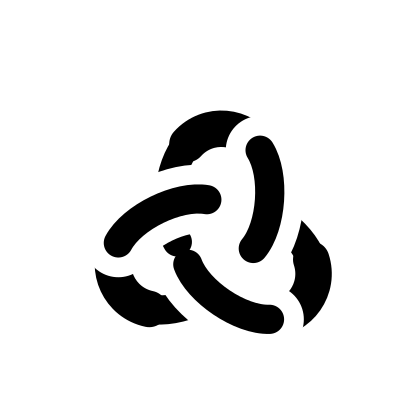

In [4]:
outer, coords = crossing_coordinates(trefoil)
print(f"chosen outer face: {outer}")
print("id  kind       x          y       radius")
for index, kind, x, y, radius in coords:
    print(f"{index:2d}  {kind:5s}  {x:9.5f}  {y:9.5f}  {radius:8.5f}")

show_svg(render_svg(trefoil))


## Choosing the outer face

The same embedding can look very different depending on which face is chosen as infinity.
Rideout's blog uses a simple and effective heuristic: prefer a face with many boundary
edges, because tiny outer rings can make some crossings visually disappear. The next image
shows all outer-face choices for `8_11`.


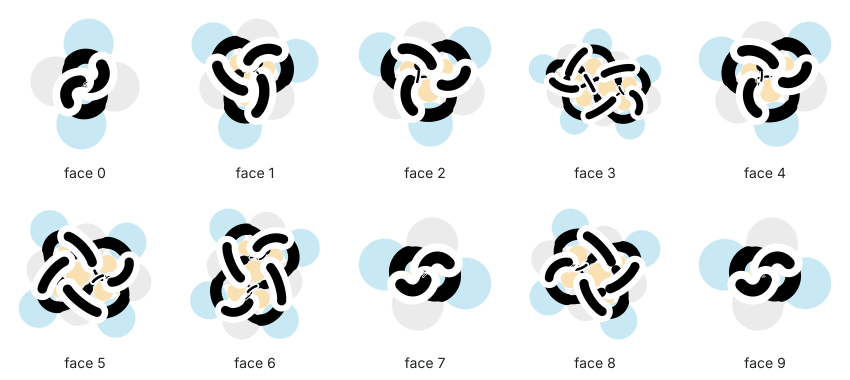

In [5]:
knot_8_11 = nodes_from_gauss(GAUSS_EXAMPLES["8_11"])
faces = face_ids(knot_8_11)
items = [
    {"label": f"face {i}", "nodes": knot_8_11, "outer_face": i, "show_circles": True}
    for i in range(len(faces))
]
show_svg(gallery_svg(items, columns=5, cell_width=170, cell_height=190))


## Rendering the crossings

The geometric shadow is already planar. To turn it into a knot diagram, draw the under-strand
first, draw a wider white stroke where the over-strand should pass, then draw the over-strand.
The blog's production renderer goes further and converts variable-width Bezier strokes into
filled outlines; this notebook keeps SVG strokes so the example remains compact.


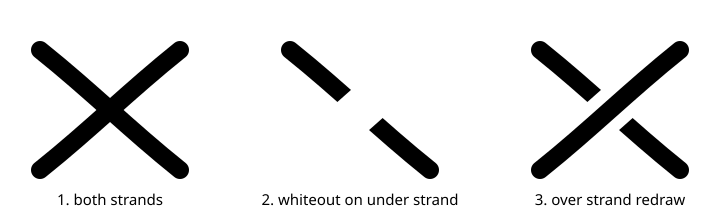

In [6]:
def crossing_layers_demo():
    return '''<svg xmlns="http://www.w3.org/2000/svg" width="720" height="220" viewBox="0 0 720 220">
    <rect width="100%" height="100%" fill="white"/>
    <g transform="translate(110 110)">
      <path d="M -70 -60 C -20 -20, 20 20, 70 60" stroke="black" stroke-width="18" fill="none" stroke-linecap="round"/>
      <path d="M -70 60 C -20 20, 20 -20, 70 -60" stroke="black" stroke-width="18" fill="none" stroke-linecap="round"/>
      <text x="0" y="95" text-anchor="middle" font-family="ui-sans-serif, sans-serif" font-size="15">1. both strands</text>
    </g>
    <g transform="translate(360 110)">
      <path d="M -70 -60 C -20 -20, 20 20, 70 60" stroke="black" stroke-width="18" fill="none" stroke-linecap="round"/>
      <path d="M -70 60 C -20 20, 20 -20, 70 -60" stroke="white" stroke-width="42" fill="none" stroke-linecap="round"/>
      <text x="0" y="95" text-anchor="middle" font-family="ui-sans-serif, sans-serif" font-size="15">2. whiteout on under strand</text>
    </g>
    <g transform="translate(610 110)">
      <path d="M -70 -60 C -20 -20, 20 20, 70 60" stroke="black" stroke-width="18" fill="none" stroke-linecap="round"/>
      <path d="M -70 60 C -20 20, 20 -20, 70 -60" stroke="white" stroke-width="42" fill="none" stroke-linecap="round"/>
      <path d="M -70 60 C -20 20, 20 -20, 70 -60" stroke="black" stroke-width="18" fill="none" stroke-linecap="round"/>
      <text x="0" y="95" text-anchor="middle" font-family="ui-sans-serif, sans-serif" font-size="15">3. over strand redraw</text>
    </g>
    </svg>'''

show_svg(crossing_layers_demo())


## More examples

These examples use enhanced Gauss codes copied from the source material for the blog post.
The same rendering function is used for every knot; there are no per-knot coordinates or
manual layout tweaks.


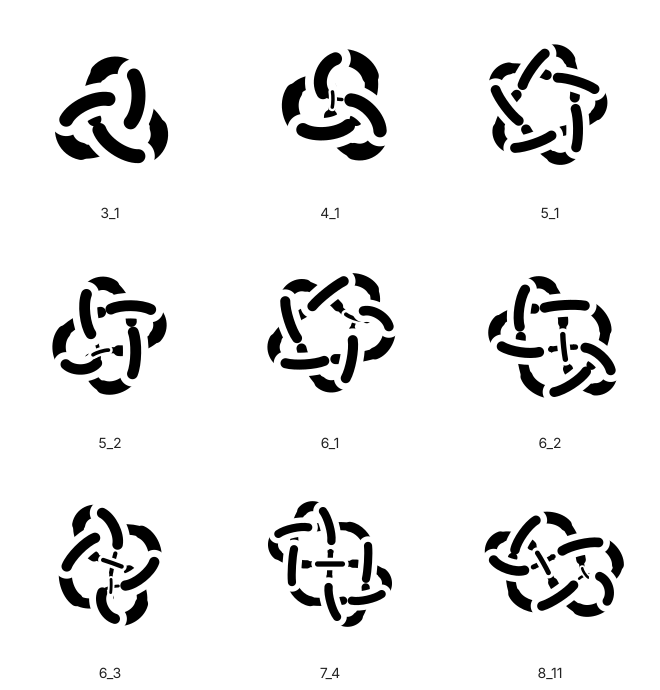

In [7]:
example_names = ["3_1", "4_1", "5_1", "5_2", "6_1", "6_2", "6_3", "7_4", "8_11"]
items = [
    {"label": name, "nodes": nodes_from_gauss(GAUSS_EXAMPLES[name])}
    for name in example_names
]
show_svg(gallery_svg(items, columns=3, cell_width=220, cell_height=230))


## Notes and limitations

- The code here is for single-component classical knots. Multi-component links need separate
  component traversal in the Gauss and PD helpers.
- A plain signed Gauss word requires the Kauffman orientation recovery step; the enhanced
  `oa` / `uc` form stores that bit explicitly.
- The layout preserves the embedding. It does not try to simplify a non-minimal input code,
  so minimality comes from the chosen PD or Gauss code.
- The production blog renderer uses filled variable-width Bezier outlines. For a notebook,
  SVG strokes plus the whiteout layer are much easier to inspect.

References: Rideout's SVG knots post, Knot Atlas PD notation, Kauffman's *Virtual Knot
Theory*, and Collins-Stephenson circle packing.
